## Step 3: Indice de cyclabilité
Ce notebook calcul un score de cyclabilité sur chaque tronçon du réseau: 
- un indice globale
- un sous-indice par catégorie (infrastructure, équipement, sécurité, confort, attractivité)

### ⚠️ MODIFICATION GEO-WEIGHTING (Claude, 2026-09-23)

Option `GEO_WEIGHTING` (cellule des paramètres) : **pondération urbain / non urbain au niveau des tronçons**.

| Étape | Changement |
|---|---|
| Paramètres | `GEO_WEIGHTING`, `type_urbain`, `type_non_urbain`, `tache_urbaine_path`. Sortie dans `step-3_geo_weighted` |
| Chargement des poids | Les deux fichiers sont fusionnés. Les colonnes de structure (Class, impact, buffer, clip, NaN) doivent être identiques, sinon erreur. Les poids deviennent `initial_weight_urbain / _non_urbain` et `class_weight_urbain / _non_urbain` |
| **Nouvelle cellule** après le renommage | Classement des tronçons : `urbain = 1` si le milieu du tronçon est dans la tache urbaine |
| Indice principal | Chaque tronçon prend les poids de son régime, divisés par leur somme (moyenne pondérée), puis le **même min-max global** qu'avant |
| Sous-indices par classe | Même logique avec `class_weight_*` |

Inchangé : normalisation et inversion des attributs (communes aux deux régimes), `walk_index_unweighted`, zones piétonnes, masque RD, export.
Avec `GEO_WEIGHTING = False`, le notebook donne exactement le même résultat qu'avant.
Chaque changement dans le code est encadré par `# >>> GEO-WEIGHTING` / `# <<< FIN GEO-WEIGHTING`, avec l'ancien code en commentaire `# AVANT :`.

In [1]:
#%% PACKAGES
# Basics
import numpy as np                                                          
from math import pi                                                            
import warnings                                                              
import os    


from datetime import datetime, timedelta
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler

# Visualization
import pandas as pd                                                          
import matplotlib.pyplot as plt                                                
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import numpy as np
import seaborn as sns; sns.set_theme(style='white')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator

# Display the map in the notebook
from IPython.display import display
# Display all columns in a dataframe
pd.set_option('display.max_columns', None)

**Load attributes**

In [2]:
operation_crs = "EPSG:2056"  # Swiss coordinate system
target_crs = "EPSG:4326"  # WGS84 coordinate system

print("Set parameters : GG or GE, bike or walk")
territory = 'GG' # GG or GE
network = "walk"  # walk or bike
type="geo_weighted" # rural_loisir or urbain_fonctionnel or unweighted for unweighted

input_file_path = '../../Data/input'
output_step1_path=f"../../Data/output/{network}/{territory}/step-1"
output_step2_path=f"../../Data/output/{network}/{territory}/step-2"
output_step3_path=f"../../Data/output/{network}/{territory}/step-3_{type}"
save_path = f"../../Data/output/{network}/{territory}/step-3_{type}"
include = f"include_in_index_{territory}"

index_col = f"{network}_index"

# RD hors agglo mask: only relevant for the walk index on Grand Geneve.
enable_rd_hors_agglo_mask = True
apply_rd_hors_agglo_mask = enable_rd_hors_agglo_mask and territory == "GG" and network == "walk"

# >>> GEO-WEIGHTING (Claude, 2026-09-23) : pondération urbain / non urbain au niveau des tronçons
# Si True : chaque tronçon est classé urbain / non urbain (milieu du tronçon dans la tache urbaine),
# puis son indice est calculé avec les poids du fichier correspondant.
# Si False : le notebook fonctionne exactement comme avant (un seul fichier de poids = `type`).
GEO_WEIGHTING = True
type_urbain = "urbain_fonctionnel"      # attributs_info_{network}_{type_urbain}.xlsx
type_non_urbain = "rural_loisir"        # attributs_info_{network}_{type_non_urbain}.xlsx
tache_urbaine_path = f"{input_file_path}/network_agreg/AGGLO_TACHE_URBAINE_2022.gpkg"  # adapter le chemin

if GEO_WEIGHTING:
    type = "geo_weighted"
    output_step3_path = f"../../Data/output/{network}/{territory}/step-3_{type}"
    save_path = f"../../Data/output/{network}/{territory}/step-3_{type}"
# <<< FIN GEO-WEIGHTING


Set parameters : GG or GE, bike or walk


In [3]:

dirpath = output_step3_path
os.makedirs(dirpath, exist_ok=True)

#Read the files
IndexRaw = gpd.read_parquet(f'{output_step2_path}/step2_features.parquet')

# >>> GEO-WEIGHTING : deux fichiers de poids fusionnés en un seul attributs_info
# AVANT : attributs_info = pd.read_excel(f"{input_file_path}/attributs/attributs_info_{network}_{type}.xlsx", sheet_name="attributs_info")
def _read_included_attributs(t):
    df = pd.read_excel(f"{input_file_path}/attributs/attributs_info_{network}_{t}.xlsx", sheet_name="attributs_info")
    m = df[include].astype(str).str.strip().str.lower().eq("true")
    return df.loc[m].copy()

def load_geo_weighted_attributs_info():
    """Fusionne les fichiers urbain et non urbain.
    - Attributs = union des attributs inclus dans l'un OU l'autre (poids 0 dans le régime où il est exclu).
    - Les colonnes de structure (Class, impact, buffer, clip, missing_value_strategy) doivent être
      identiques dans les deux fichiers, sinon la normalisation ne serait pas commune -> erreur.
    - initial_weight et class_weight deviennent *_urbain et *_non_urbain."""
    info_u = _read_included_attributs(type_urbain)
    info_r = _read_included_attributs(type_non_urbain)

    struct_cols = [c for c in ["Class", "impact_attribut", f"buffer_size_{territory}", f"clip_{territory}",
                               "missing_value_strategy"] if c in info_u.columns and c in info_r.columns]
    common = info_u.merge(info_r, on="attribute", suffixes=("_u", "_r"))
    diffs = []
    for c in struct_cols:
        a, b = common[f"{c}_u"], common[f"{c}_r"]
        differ = ~((a == b) | (a.isna() & b.isna()))
        diffs += [f"{attr}.{c}: {x!r} (urbain) vs {y!r} (non urbain)"
                  for attr, x, y in zip(common.loc[differ, "attribute"], a[differ], b[differ])]
    if diffs:
        raise ValueError("Colonnes de structure différentes entre les deux fichiers de poids :\n" + "\n".join(diffs))

    # Colonnes de structure : on prend la ligne du fichier urbain, sinon celle du non urbain
    merged = pd.concat([info_u, info_r[~info_r["attribute"].isin(info_u["attribute"])]], ignore_index=True)
    for w in ["initial_weight", "class_weight"]:
        merged[f"{w}_urbain"] = merged["attribute"].map(info_u.set_index("attribute")[w]).fillna(0.0)
        merged[f"{w}_non_urbain"] = merged["attribute"].map(info_r.set_index("attribute")[w]).fillna(0.0)
    merged = merged.drop(columns=["initial_weight", "class_weight"])
    merged[include] = True  # déjà filtré
    print(f"GEO_WEIGHTING : {len(info_u)} attributs urbains, {len(info_r)} non urbains, {len(merged)} au total")
    return merged

if GEO_WEIGHTING:
    attributs_info = load_geo_weighted_attributs_info()
else:
    attributs_info = pd.read_excel(f"{input_file_path}/attributs/attributs_info_{network}_{type}.xlsx", sheet_name="attributs_info")
# <<< FIN GEO-WEIGHTING

# Keep only attributes explicitly included in the index.
# Excel may read True/False either as booleans or as strings depending on the column.
include_mask = (
    attributs_info[include]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)
attributs_info = attributs_info.loc[include_mask].copy()

# Missing value strategy used before normalization.
if "missing_value_strategy" not in attributs_info.columns:
    attributs_info["missing_value_strategy"] = "zero_if_missing"

attributs_info["missing_value_strategy"] = (
    attributs_info["missing_value_strategy"]
    .fillna("zero_if_missing")
    .astype(str)
    .str.strip()
    .str.lower()
)

valid_missing_value_strategies = {
    "zero_if_missing",
    "median_if_missing",
    "mean_if_missing",
    "keep_nan",
}
invalid_missing_value_strategies = sorted(
    set(attributs_info["missing_value_strategy"]) - valid_missing_value_strategies
)
if invalid_missing_value_strategies:
    raise ValueError(
        "Invalid missing_value_strategy values for included attributes: "
        f"{invalid_missing_value_strategies}. "
        f"Allowed values: {sorted(valid_missing_value_strategies)}"
    )

attributs_info

GEO_WEIGHTING : 20 attributs urbains, 20 non urbains, 20 au total


,Class,meta_attribute,attribute,include_in_index_GG,include_in_index_GE,source_type_GE,source_path_GE,file_name_GE,source_type_VD,source_path_VD,file_name_VD,source_type_FR,source_path_FR,file_name_FR,source_type_GG,source_path_GG,file_name_GG,merge_rule_GG,buffer_size_GG,buffer_size_GE,impact_attribut,geometry_type_GE,how_GE,value_column_GE,geometry_type_GG,how_GG,value_column_GG,clip_GG,clip_GE,missing_value_strategy,filter_column,filter_values,crs,save_format,Commentaire,initial_weight_urbain,initial_weight_non_urbain,class_weight_urbain,class_weight_non_urbain
0,Attractivité,lac_cours_deau,lac_cours_deau,True,True,sitg,attributs/GE/lac_cours_deau,CAD_NATURE_SOL-SHP/CAD_NATURE_SOL.shp,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,50,50,favorable,polygon,presence,NaN,polygon,presence,NaN,NaN,NaN,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",ok,0.5,0.5,0.5,0.5
1,Attractivité,fontaine,fontaine,True,True,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,50,50,favorable,point,count,NaN,point,count,NaN,2.0,2.0,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",ok,0.5,0.0,0.5,0.5
2,Attractivité,espaces_ouverts,espaces_ouverts,True,True,sitg,attributs/GE/espaces_ouverts,OBS_EQUIPEMENTS_ESPACES_PUB-SHP/OBS_EQUIPEMENT...,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,1,1,favorable,polygon,presence,NaN,polygon,presence,NaN,NaN,2.0,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",TB,0.5,0.0,0.5,0.5
3,Attractivité,amenite,rez_actif,True,True,sitg,attributs/GE/rez_actif,REG_ENTREPRISE_ETABLISSEMENT-SHP/REG_ENTREPRIS...,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,50,50,favorable,point,count,NaN,point,count,NaN,4.0,10.0,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",TB,0.5,0.0,0.5,0.5
4,Attractivité,transport_public,tp,True,True,sitg,attributs/GE/tp,TPG_ARRETS-SHP/TPG_ARRETS.shp,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,150,150,favorable,point,presence,NaN,point,presence,NaN,NaN,NaN,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",TB,0.5,0.0,0.5,0.5
5,Attractivité,amenite,amenite,True,True,sitg,attributs/GE/amenite,REG_ENTREPRISE_ETABLISSEMENT-SHP/REG_ENTREPRIS...,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,75,75,favorable,point,count,NaN,point,count,NaN,2.0,6.0,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",TB,0.5,0.0,0.5,0.5
6,Commodité,temperature,temperature,True,True,sitg,attributs/GE/temperature,CLIMAT_TEMPERATURE_14H00_P1_2020/CLIMAT_TEMPER...,NaN,NaN,NaN,NaN,NaN,NaN,opendata,attributs/GG/temperature,LST_GrandGeneve_2023.tif,NaN,100,250,defavorable,point,raster,temperature,point,raster,temperature,40.0,40.0,keep_nan,filtered,1,2056,"parquet, csv, gpkg",TB,0.5,0.5,0.5,0.5
7,Commodité,conflit_md,conflit_md,True,True,sitg,attributs/GE/network_couche_OCT.shp,RP_final_25112025.shp,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,1,1,defavorable,line,mean,Partage_us_score,point,sum,severity_score,72.0,2.0,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",TB,0.5,0.0,0.5,0.5
8,Commodité,canopee,canopee,True,True,sitg,attributs/GE/canopee,SIPV_ICA_MNC_2023-SHP/SIPV_ICA_MNC_2023.shp,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,30,30,favorable,polygon,area_ratio,NaN,polygon,area_ratio,NaN,NaN,NaN,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",ok,0.5,0.5,0.5,0.5
9,Commodité,banc,banc,True,True,osm,attributs/GE/osm,osm_attributes.gpkg,NaN,NaN,NaN,NaN,NaN,NaN,osm,attributs/GG/osm,osm_attributes.gpkg,NaN,10,10,favorable,point,count,NaN,point,presence,NaN,NaN,4.0,zero_if_missing,filtered,1,2056,"parquet, csv, gpkg",ok,0.5,0.0,0.5,0.5


In [4]:
print(attributs_info['attribute'].to_list())

['lac_cours_deau', 'fontaine', 'espaces_ouverts', 'rez_actif', 'tp', 'amenite', 'temperature', 'conflit_md', 'canopee', 'banc', 'toilette', 'air', 'connectivite', 'chemin', 'pente', 'accident', 'zone_apaisee', 'zone_pietonne', 'vitesse', 'eclairage']


**Rename columns and clip if necessary**

In [5]:

# Get list of attributes to include (from attributs_info)
attributes_to_include = attributs_info['attribute'].tolist()

# Create mapping for processed columns based on actual column names in IndexRaw
attribute_mapping = {}
for _, row in attributs_info.iterrows():
    old_name = f"{row['attribute']}_{int(row[f'buffer_size_{territory}'])}"
    new_name = row['attribute']
    # Only add to mapping if column exists in IndexRaw
    if old_name in IndexRaw.columns:
        attribute_mapping[old_name] = new_name
    else:
        print(f"⚠️ Column '{old_name}' not found in IndexRaw")

# Apply renaming only to mapped columns
Indexv1 = IndexRaw.rename(columns=attribute_mapping)

# Keep only geometry columns + renamed attribute columns
geometry_cols = ['segment_id', 'geometry', 'length', 'u', 'v']
missing_attribute_cols = [col for col in attributes_to_include if col not in Indexv1.columns]
if missing_attribute_cols:
    raise KeyError(f"Missing expected attribute columns after renaming: {missing_attribute_cols}")

cols_to_keep = [col for col in geometry_cols if col in Indexv1.columns] + attributes_to_include

# Filter to keep only relevant columns
Indexv1 = Indexv1[cols_to_keep]

# Apply missing value strategy before normalization.
missing_strategy_by_attribute = attributs_info.set_index("attribute")["missing_value_strategy"].to_dict()
nan_report_rows = []

for attr in attributes_to_include:
    strategy = missing_strategy_by_attribute.get(attr, "zero_if_missing")
    n_nan_before = int(Indexv1[attr].isna().sum())
    fill_value = np.nan

    if n_nan_before > 0:
        if strategy == "zero_if_missing":
            fill_value = 0
            Indexv1[attr] = Indexv1[attr].fillna(fill_value)
        elif strategy == "median_if_missing":
            fill_value = Indexv1[attr].median(skipna=True)
            if pd.notna(fill_value):
                Indexv1[attr] = Indexv1[attr].fillna(fill_value)
        elif strategy == "mean_if_missing":
            fill_value = Indexv1[attr].mean(skipna=True)
            if pd.notna(fill_value):
                Indexv1[attr] = Indexv1[attr].fillna(fill_value)
        elif strategy == "keep_nan":
            pass

    n_nan_after = int(Indexv1[attr].isna().sum())
    nan_report_rows.append({
        "attribute": attr,
        "missing_value_strategy": strategy,
        "n_nan_before": n_nan_before,
        "n_nan_after": n_nan_after,
        "n_nan_replaced": n_nan_before - n_nan_after,
        "pct_rows_before": round(n_nan_before / len(Indexv1) * 100, 4),
        "fill_value": fill_value,
    })

nan_report = pd.DataFrame(nan_report_rows)
total_nan_before = int(nan_report["n_nan_before"].sum())
total_nan_replaced = int(nan_report["n_nan_replaced"].sum())
total_nan_kept = int(nan_report["n_nan_after"].sum())

print("="*80)
print("MISSING VALUES BEFORE INDEX COMPUTATION")
print("="*80)
print(f"Total NaN before strategy: {total_nan_before:,}")
print(f"Total NaN replaced:        {total_nan_replaced:,}")
print(f"Total NaN kept:            {total_nan_kept:,}")

if total_nan_before > 0:
    display(nan_report.loc[nan_report["n_nan_before"] > 0])
else:
    print("No NaN found in selected index attributes.")

nan_report.to_csv(f"{output_step3_path}/nan_replacement_report.csv", index=False)
print("="*80)

# Debug info
print(f"✓ Kept {len([c for c in geometry_cols if c in Indexv1.columns])} geometry columns + {len(attributes_to_include)} attributes")
print(f"Final columns: {Indexv1.columns.tolist()}")

print('Crop outliers if necessary: --> see Bikability Amsterdam notebook')
Indexv2 = Indexv1.copy()

# Adding intervals (for factors where we have an interval of interest)
# Indexv2['stationnement_genant'] = Indexv1['stationnement_genant'].clip(upper=5)

MISSING VALUES BEFORE INDEX COMPUTATION
Total NaN before strategy: 0
Total NaN replaced:        0
Total NaN kept:            0
No NaN found in selected index attributes.
✓ Kept 3 geometry columns + 20 attributes
Final columns: ['segment_id', 'geometry', 'length', 'lac_cours_deau', 'fontaine', 'espaces_ouverts', 'rez_actif', 'tp', 'amenite', 'temperature', 'conflit_md', 'canopee', 'banc', 'toilette', 'air', 'connectivite', 'chemin', 'pente', 'accident', 'zone_apaisee', 'zone_pietonne', 'vitesse', 'eclairage']
Crop outliers if necessary: --> see Bikability Amsterdam notebook


**GEO-WEIGHTING : classer chaque tronçon en urbain / non urbain** *(ajout Claude, 2026-09-23)*

Un tronçon est **urbain** si son **milieu** est dans la tache urbaine (limite comprise). Les tronçons font au plus 50 m, donc prendre le milieu revient pratiquement à regarder la majorité de la longueur.
La colonne `urbain` (0/1) est gardée jusqu'à l'export. Après l'agrégation au carreau (notebook 3_2), sa moyenne donne la **part de réseau urbain** du carreau.

In [6]:
# >>> GEO-WEIGHTING : classement urbain / non urbain des tronçons (cellule ajoutée)
if GEO_WEIGHTING:
    assert Indexv1.index.is_unique, "L'index de Indexv1 doit être unique"
    tache_urbaine = gpd.read_file(tache_urbaine_path)
    tache_urbaine["geometry"] = tache_urbaine.geometry.force_2d().make_valid()  # couche ZM + 1 géométrie invalide
    tache_urbaine = tache_urbaine.to_crs(operation_crs)[["geometry"]]

    midpoints = gpd.GeoDataFrame(
        geometry=Indexv1.geometry.to_crs(operation_crs).interpolate(0.5, normalized=True),
        index=Indexv1.index, crs=operation_crs,
    )
    in_tache = gpd.sjoin(midpoints, tache_urbaine, how="inner", predicate="intersects").index.unique()

    Indexv1["urbain"] = 0
    Indexv1.loc[in_tache, "urbain"] = 1
    Indexv1["urbain"] = Indexv1["urbain"].astype("int8")

    length_urb = Indexv1.loc[Indexv1["urbain"] == 1, "length"].sum() if "length" in Indexv1 else np.nan
    print(f"Tronçons urbains : {Indexv1['urbain'].sum():,} / {len(Indexv1):,} "
          f"({Indexv1['urbain'].mean():.1%} des tronçons, {length_urb / Indexv1['length'].sum():.1%} de la longueur)")
else:
    print("GEO_WEIGHTING = False : pas de classement urbain / non urbain")
# <<< FIN GEO-WEIGHTING

/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/venv/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


Tronçons urbains : 327,016 / 732,164 (44.7% des tronçons, 38.3% de la longueur)


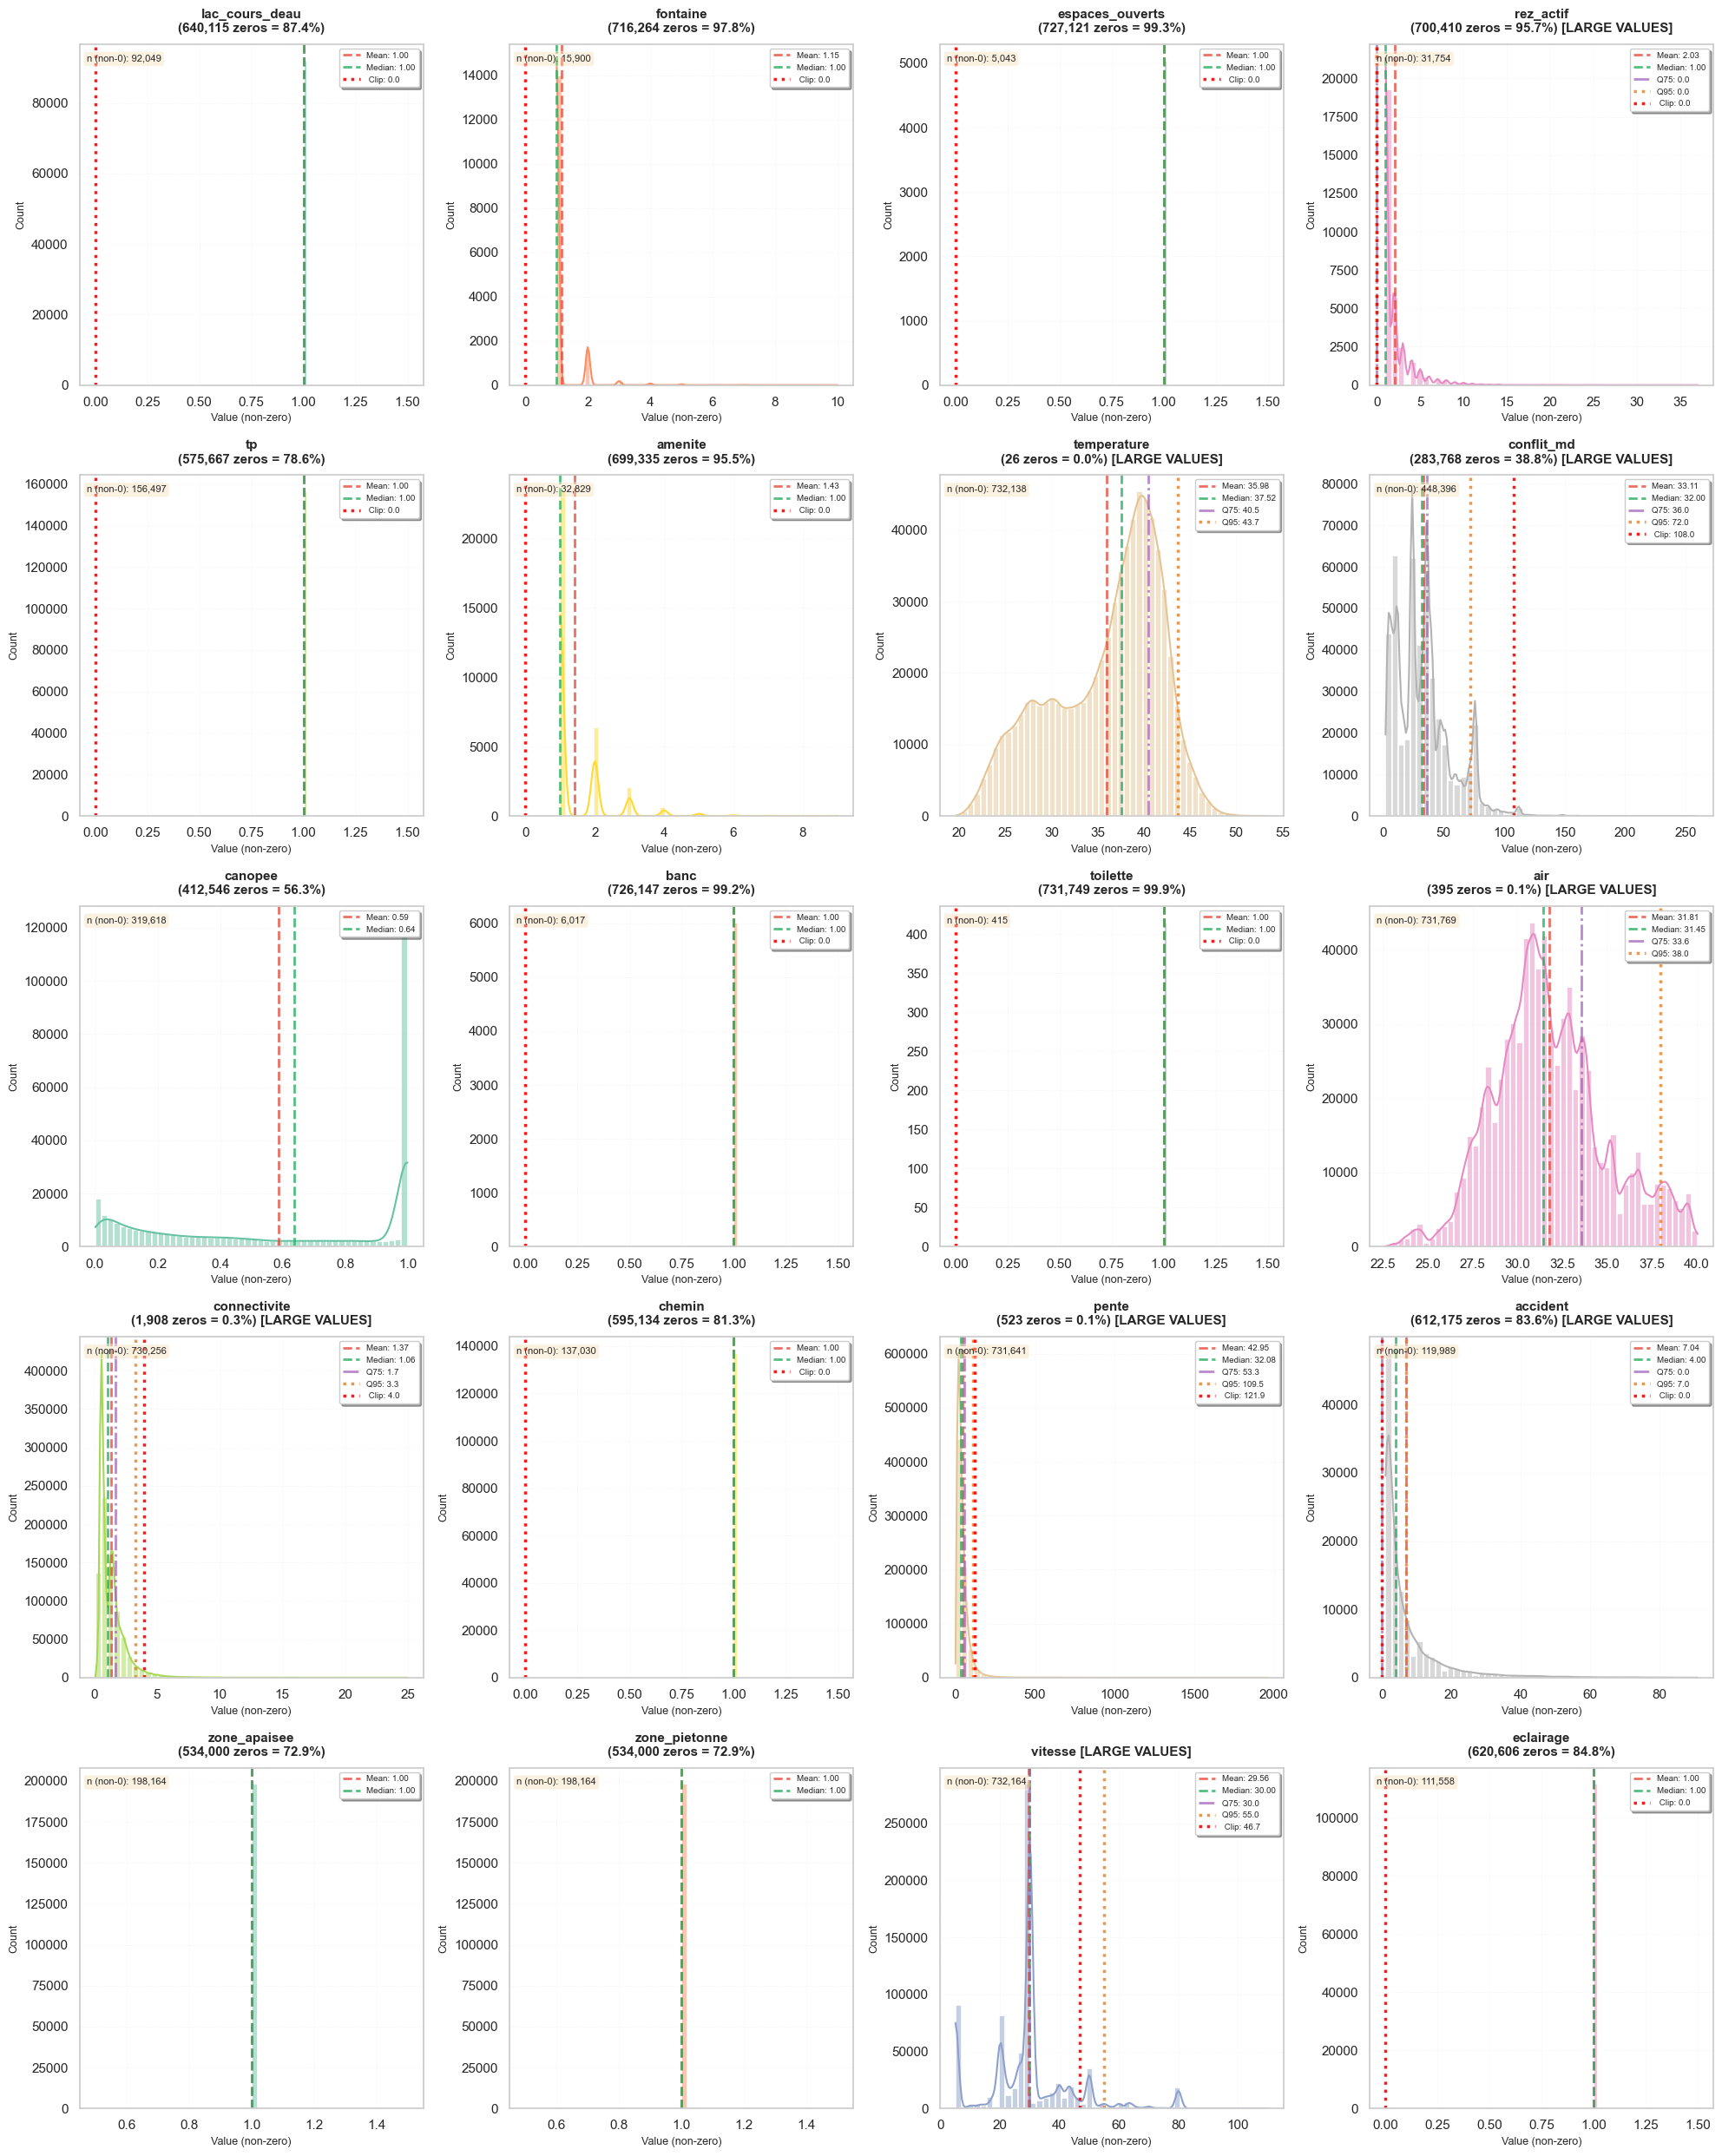


 COMPREHENSIVE STATISTICS TABLE (All Values)

ARGE VALUE ATTRIBUTES (max > 10) - Consider Q75 or Q95 for clipping:
   • rez_actif:
     Q75=0.00 | Q95=0.00 | Max=37.00
   • temperature:
     Q75=40.51 | Q95=43.67 | Max=53.41
   • conflit_md:
     Q75=36.00 | Q95=72.00 | Max=260.00
   • air:
     Q75=33.59 | Q95=38.00 | Max=40.07
   • connectivite:
     Q75=1.72 | Q95=3.31 | Max=24.98
   • pente:
     Q75=53.31 | Q95=109.50 | Max=1960.95
   • accident:
     Q75=0.00 | Q95=7.00 | Max=91.00
   • vitesse:
     Q75=30.00 | Q95=55.00 | Max=110.00

 ATTRIBUTES WITH EXTREME OUTLIERS (consider clipping):
   • lac_cours_deau: 92049 outliers detected
     → Suggested clip at 0.00 (current max: 1.00)
   • fontaine: 15900 outliers detected
     → Suggested clip at 0.00 (current max: 10.00)
   • espaces_ouverts: 5043 outliers detected
     → Suggested clip at 0.00 (current max: 1.00)
   • rez_actif: 31754 outliers detected
     → Suggested clip at 0.00 (current max: 37.00)
   • tp: 156497 outliers 

In [7]:
# Plot histograms (non-zero) + comprehensive statistics table
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style='whitegrid', palette='deep')

attr_cols = [col for col in Indexv2.columns if col in attributes_to_include]
n_attrs = len(attr_cols)
n_cols = 4
n_rows = int(np.ceil(n_attrs / n_cols))

# ============== BUILD STATISTICS TABLE FIRST ==============
stats_data = []
for attr in attr_cols:
    data = Indexv2[attr].dropna()
    non_zero = data[data > 0]
    
    zeros = (data == 0).sum()
    zero_pct = zeros / len(data) * 100
    
    # Check for extreme outliers (values > Q3 + 3*IQR)
    q1, q3 = data.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_fence = q3 + 3 * iqr
    outliers = (data > upper_fence).sum()
    
    # Suggested clip value (Q3 + 2*IQR is more conservative)
    suggested_clip = q3 + 2 * iqr if outliers > 0 else None
    
    # Determine if attribute has large values (not boolean/score)
    is_large_value = data.max() > 10
    
    stats_data.append({
        'Attribute': attr,
        'Count': len(data),
        'Zeros': zeros,
        'Zero %': zero_pct,
        'Min': data.min(),
        'Q25': q1,
        'Median': data.median(),
        'Q75': q3,
        'Q95': data.quantile(0.95),
        'Max': data.max(),
        'Mean': data.mean(),
        'Std': data.std(),
        'Mean (non-0)': non_zero.mean() if len(non_zero) > 0 else np.nan,
        'Median (non-0)': non_zero.median() if len(non_zero) > 0 else np.nan,
        'Outliers (>Q3+3*IQR)': outliers,
        'Suggested Clip': suggested_clip,
        'Large Values': is_large_value
    })

stats_df = pd.DataFrame(stats_data)

# ============== PLOT HISTOGRAMS (NON-ZERO VALUES ONLY) ==============
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() if n_attrs > 1 else [axes]

colors = sns.color_palette('Set2', n_attrs)

for idx, attr in enumerate(attr_cols):
    ax = axes[idx]
    data = Indexv2[attr].dropna()
    non_zero_data = data[data > 0]
    
    zeros = (data == 0).sum()
    zero_pct = zeros / len(data) * 100
    is_large_value = data.max() > 10
    
    if len(non_zero_data) > 0:
        # Plot histogram
        sns.histplot(
            non_zero_data, 
            bins=50, 
            kde=True, 
            color=colors[idx % len(colors)],
            edgecolor='white',
            linewidth=1.2,
            ax=ax,
            stat='count'
        )
        
        # Add stats lines (for NON-ZERO values)
        mean_nz = non_zero_data.mean()
        median_nz = non_zero_data.median()
        ax.axvline(mean_nz, color='#e74c3c', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_nz:.2f}', alpha=0.8)
        ax.axvline(median_nz, color='#27ae60', linestyle='--', linewidth=2, 
                   label=f'Median: {median_nz:.2f}', alpha=0.8)
        
        # FOR LARGE VALUES: Add Q75 and Q95 lines
        if is_large_value:
            q75 = data.quantile(0.75)
            q95 = data.quantile(0.95)
            ax.axvline(q75, color='#9b59b6', linestyle='-.', linewidth=2, 
                       label=f'Q75: {q75:.1f}', alpha=0.7)
            ax.axvline(q95, color='#e67e22', linestyle=':', linewidth=2.5, 
                       label=f'Q95: {q95:.1f}', alpha=0.8)
        
        # Mark suggested clip value if exists
        clip_val = stats_df.loc[stats_df['Attribute'] == attr, 'Suggested Clip'].values[0]
        if pd.notna(clip_val) and clip_val < non_zero_data.max():
            ax.axvline(clip_val, color='red', linestyle=':', linewidth=2.5, 
                       label=f' Clip: {clip_val:.1f}', alpha=0.9)
    else:
        # If no non-zero data, show empty plot with message
        ax.text(0.5, 0.5, 'All zeros', transform=ax.transAxes, 
                ha='center', va='center', fontsize=12, color='gray')
    
    # Title with zero info and type indicator
    title = f'{attr}'
    if zeros > 0:
        title += f'\n({zeros:,} zeros = {zero_pct:.1f}%)'
    if is_large_value:
        title += ' [LARGE VALUES]'
    
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Value (non-zero)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=7, frameon=True, shadow=True, fancybox=True, loc='upper right')
    ax.grid(alpha=0.3, linestyle=':', linewidth=0.5)
    
    # Stats box
    if len(non_zero_data) > 0:
        n_nz = len(non_zero_data)
        ax.text(0.02, 0.97, f'n (non-0): {n_nz:,}', 
                transform=ax.transAxes, ha='left', va='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4))

for idx in range(n_attrs, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(f'{output_step3_path}/attributes_distributions_nonzero.png', dpi=200, bbox_inches='tight')
plt.show()

# ============== DISPLAY STATISTICS TABLE ==============
print("\n" + "="*120)
print(" COMPREHENSIVE STATISTICS TABLE (All Values)")
print("="*120)

# Format for display
display_df = stats_df.copy()
for col in ['Min', 'Q25', 'Median', 'Q75', 'Q95', 'Max', 'Mean', 'Std', 'Mean (non-0)', 'Median (non-0)', 'Suggested Clip']:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f'{x:.3f}' if pd.notna(x) else '-')
display_df['Zero %'] = display_df['Zero %'].apply(lambda x: f'{x:.1f}%')

# Separate attributes by type
large_value_attrs = stats_df[stats_df['Large Values'] == True]['Attribute'].tolist()
if large_value_attrs:
    print("\nARGE VALUE ATTRIBUTES (max > 10) - Consider Q75 or Q95 for clipping:")
    for attr in large_value_attrs:
        row = stats_df[stats_df['Attribute'] == attr].iloc[0]
        print(f"   • {attr}:")
        print(f"     Q75={row['Q75']:.2f} | Q95={row['Q95']:.2f} | Max={row['Max']:.2f}")

# Highlight attributes needing clipping
needs_clipping = stats_df[stats_df['Outliers (>Q3+3*IQR)'] > 0]['Attribute'].tolist()
if needs_clipping:
    print("\n ATTRIBUTES WITH EXTREME OUTLIERS (consider clipping):")
    for attr in needs_clipping:
        row = stats_df[stats_df['Attribute'] == attr].iloc[0]
        print(f"   • {attr}: {row['Outliers (>Q3+3*IQR)']} outliers detected")
        print(f"     → Suggested clip at {row['Suggested Clip']:.2f} (current max: {row['Max']:.2f})")

print("\n" + display_df.to_string(index=False))
print("="*120)

# Save stats to CSV
stats_df.to_csv(f'{output_step3_path}/attributes_statistics.csv', index=False)
print(f"\n Statistics saved to: {output_step3_path}/attributes_statistics.csv")

# ============== GENERATE CLIPPING CODE ==============
print("\n" + "="*80)
print("📝 SUGGESTED CLIPPING CODE (choose threshold):")
print("="*80)

# For large value attributes, suggest Q75 or Q95
for attr in large_value_attrs:
    row = stats_df[stats_df['Attribute'] == attr].iloc[0]
    q75 = row['Q75']
    q95 = row['Q95']
    print(f"\n# {attr} (Large values):")
    print(f"# Option 1 (conservative - Q75): Indexv2['{attr}'] = Indexv2['{attr}'].clip(upper={q75:.2f})")
    print(f"# Option 2 (moderate - Q95):     Indexv2['{attr}'] = Indexv2['{attr}'].clip(upper={q95:.2f})")

# For outlier attributes
if needs_clipping:
    print("\n# Extreme outliers (automatic suggestion):")
    for attr in needs_clipping:
        if attr not in large_value_attrs:  # avoid duplicates
            clip_val = stats_df[stats_df['Attribute'] == attr]['Suggested Clip'].values[0]
            print(f"Indexv2['{attr}'] = Indexv2['{attr}'].clip(upper={clip_val:.2f})")

print("="*80)

**Normalize and center**

In [8]:
# ============== CLIPPING BEFORE NORMALIZATION ==============
print("="*80)
print("✂️  APPLYING CLIPPING (based on attributs_info.clip column)")
print("="*80)

Indexv2 = Indexv1.copy()

for _, row in attributs_info.iterrows():
    attr = row['attribute']
    clip_value = row[f"clip_{territory}"]  # Use the territory-specific clip value
    
    if attr in Indexv2.columns:
        if pd.notna(clip_value):
            original_max = Indexv2[attr].max()
            Indexv2[attr] = Indexv2[attr].clip(upper=clip_value)
            n_clipped = (Indexv1[attr] > clip_value).sum()
            print(f"✂️  {attr}: clipped at {clip_value:.2f} (was {original_max:.2f}, {n_clipped} values affected)")
        else:
            print(f"   {attr}: no clipping (clip=NaN)")
    else:
        print(f"⚠️  {attr}: not found in Indexv2")

print("="*80)

# ============== NORMALIZATION + OPTIONAL CENTERING ==============
CENTER_AROUND_ZERO = False  # Set to False for [0, 1] range and True for [-1, 1] range

Indexv3 = Indexv2.copy()
scaler = MinMaxScaler()

print("\n" + "="*80)
if CENTER_AROUND_ZERO:
    print("📊 MIN-MAX NORMALIZATION + CENTERING (range: [-1, 1])")
else:
    print("📊 MIN-MAX NORMALIZATION (range: [0, 1])")
print("="*80)

for attribute in attributs_info['attribute']:
    if attribute in Indexv3.columns:
        # Normalize to [0, 1]
        normalized = scaler.fit_transform(Indexv3[[attribute]])
        
        if CENTER_AROUND_ZERO:
            # Center to [-1, 1]: (x * 2) - 1
            Indexv3.loc[:, attribute] = (normalized * 2 - 1).round(4)
        else:
            # Keep [0, 1]
            Indexv3.loc[:, attribute] = normalized.round(4)
    else:
        print(f"⚠️  Attribute '{attribute}' not found in Indexv3 columns.")

print("✅ Normalization complete")

# ============== INVERSE COLUMNS (for defavorable attributes) ==============
print("\n" + "="*80)
print("🔄 INVERTING DEFAVORABLE ATTRIBUTES")
print("="*80)

for _, row in attributs_info.iterrows():
    attribute_name = row['attribute']
    impact = row['impact_attribut']
    
    if attribute_name in Indexv3.columns:
        if impact == 'defavorable':
            if CENTER_AROUND_ZERO:
                # For [-1, 1]: multiply by -1
                Indexv3[attribute_name] = -Indexv3[attribute_name]
                print(f"🔄 Inverted {attribute_name}: multiplied by -1 (now favorable = positive)")
            else:
                # For [0, 1]: 1 - x
                Indexv3[attribute_name] = 1 - Indexv3[attribute_name]
                print(f"🔄 Inverted {attribute_name}: 1 - x")
    else:
        print(f"⚠️  Attribute '{attribute_name}' not found in Indexv3 columns.")

print("="*80)

# ============== SHOW DISTRIBUTION AFTER NORMALIZATION ==============
print("\n" + "="*80)
print("📊 POST-NORMALIZATION DISTRIBUTION CHECK")
print("="*80)

for attr in attributs_info['attribute'].head(5):  # Show first 5 as example
    if attr in Indexv3.columns:
        min_val = Indexv3[attr].min()
        max_val = Indexv3[attr].max()
        mean_val = Indexv3[attr].mean()
        impact = attributs_info[attributs_info['attribute'] == attr]['impact_attribut'].values[0]
        
        print(f"\n{attr} ({impact}):")
        print(f"  Range: [{min_val:.4f}, {max_val:.4f}]")
        print(f"  Mean:  {mean_val:.4f}")
        
        if CENTER_AROUND_ZERO:
            if impact == 'favorable':
                print(f"  ✅ Positive values = good Bikability")
            else:
                print(f"  ✅ Negative values = bad Bikability (inverted)")
        else:
            print(f"  ✅ Higher values = better Bikability (after inversion if needed)")

print("="*80)

✂️  APPLYING CLIPPING (based on attributs_info.clip column)
   lac_cours_deau: no clipping (clip=NaN)
✂️  fontaine: clipped at 2.00 (was 10.00, 285 values affected)
   espaces_ouverts: no clipping (clip=NaN)
✂️  rez_actif: clipped at 4.00 (was 37.00, 2743 values affected)
   tp: no clipping (clip=NaN)
✂️  amenite: clipped at 2.00 (was 9.00, 3070 values affected)
✂️  temperature: clipped at 40.00 (was 53.41, 216381 values affected)
✂️  conflit_md: clipped at 72.00 (was 260.00, 35119 values affected)
   canopee: no clipping (clip=NaN)
   banc: no clipping (clip=NaN)
   toilette: no clipping (clip=NaN)
   air: no clipping (clip=NaN)
✂️  connectivite: clipped at 5.00 (was 24.98, 9826 values affected)
   chemin: no clipping (clip=NaN)
✂️  pente: clipped at 60.00 (was 1960.95, 147442 values affected)
✂️  accident: clipped at 4.00 (was 91.00, 50053 values affected)
   zone_apaisee: no clipping (clip=NaN)
   zone_pietonne: no clipping (clip=NaN)
✂️  vitesse: clipped at 50.00 (was 110.00, 42713

In [9]:
# # SIMPLE BOXPLOTS - All attributes on same axis with Class labels
# import plotly.graph_objects as go
# import pandas as pd
# import numpy as np

# attr_cols = [col for col in Indexv3.columns if col in attributes_to_include]

# # Prepare data for boxplots
# fig = go.Figure()

# for attr in attr_cols:
#     data = Indexv3[attr].dropna()
#     impact = attributs_info[attributs_info['attribute'] == attr]['impact_attribut'].values[0]
#     cls = attributs_info[attributs_info['attribute'] == attr]['Class'].values[0]
    
#     # Color based on impact
#     color = 'darkred' if impact == 'defavorable' else 'darkgreen'
    
#     # Add boxplot
#     fig.add_trace(go.Box(
#         y=data,
#         name=f"{cls}<br><b>{attr}</b><br>({impact})",
#         boxmean='sd',
#         marker_color=color,
#         line=dict(width=1.2, color=color),
#         fillcolor=color,
#         opacity=0.6,
#         showlegend=False,
#         width=0.5
#     ))

# # Update layout
# range_str = "[-1, 1]" if CENTER_AROUND_ZERO else "[0, 1]"
# fig.update_layout(
#     title=f"Normalized Attributes Distribution {range_str}",
#     yaxis_title="Normalized Value",
#     xaxis_title="Attributes",
#     height=600,
#     width=1400,
#     template='plotly_white',
#     showlegend=False,
#     xaxis=dict(tickangle=-45, tickfont=dict(size=8))
# )

# # Add reference line at zero if centered
# if CENTER_AROUND_ZERO:
#     fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)

# # Save as PNG
# # fig.write_image(f'{output_step3_path}/attributes_normalized_boxplots.png', width=1400, height=600, scale=2)
# fig.show()

# # Print summary statistics
# print("\n" + "="*100)
# print(f"DISTRIBUTION SUMMARY {range_str}")
# print("="*100)

# summary_data = []
# for attr in attr_cols:
#     data = Indexv3[attr].dropna()
#     impact = attributs_info[attributs_info['attribute'] == attr]['impact_attribut'].values[0]
#     cls = attributs_info[attributs_info['attribute'] == attr]['Class'].values[0]
    
#     summary_data.append({
#         'Class': cls,
#         'Attribute': attr,
#         'Impact': impact,
#         'Min': data.min(),
#         'Q25': data.quantile(0.25),
#         'Median': data.median(),
#         'Q75': data.quantile(0.75),
#         'Max': data.max(),
#         'Mean': data.mean(),
#         'Std': data.std(),
#         'IQR': data.quantile(0.75) - data.quantile(0.25)
#     })

# summary_df = pd.DataFrame(summary_data)

# # Format for display
# display_df = summary_df.copy()
# for col in ['Min', 'Q25', 'Median', 'Q75', 'Max', 'Mean', 'Std', 'IQR']:
#     display_df[col] = display_df[col].apply(lambda x: f'{x:.3f}')

# print("\n" + display_df.to_string(index=False))
# print("="*100)

# # Check distribution quality
# print("\nDISTRIBUTION QUALITY:")
# for _, row in summary_df.iterrows():
#     if row['Std'] < 0.1:
#         print(f"  {row['Attribute']} ({row['Class']}): Low variance (std={row['Std']:.3f})")
#     elif row['Std'] > 0.3:
#         print(f"  {row['Attribute']} ({row['Class']}): Good spread (std={row['Std']:.3f})")
#     else:
#         print(f"  {row['Attribute']} ({row['Class']}): Moderate (std={row['Std']:.3f})")

# print(f"\nPlot saved: {output_step3_path}/attributes_normalized_boxplots.png")

In [10]:
# Calculate the Main Index Scores
Indexv4 = Indexv3.copy()

# >>> GEO-WEIGHTING : un jeu de poids par régime (la vérification des poids est la même qu'avant)
# AVANT : une seule colonne 'initial_weight' -> Zscore_weights
def _read_weights(weight_col):
    weights = {}
    for _, row in attributs_info.iterrows():
        attr = row['attribute']
        weight = row[weight_col]
        if pd.isnull(weight):
            raise ValueError(f"Weight not specified for attribute '{attr}' (found NaN) in '{weight_col}'. Please specify a value between 0 and 1.")
        if not (0 <= weight <= 1):
            raise ValueError(f"Weight for attribute '{attr}' is {weight} in '{weight_col}', but must be between 0 and 1.")
        weights[attr] = weight
    if not weights:
        raise ValueError(f"No attributes selected for {network=} {territory=} with {include=}")
    return weights

if GEO_WEIGHTING:
    Zscore_weights_urbain = _read_weights('initial_weight_urbain')
    Zscore_weights_non_urbain = _read_weights('initial_weight_non_urbain')
    for lbl, w in [("urbain", Zscore_weights_urbain), ("non_urbain", Zscore_weights_non_urbain)]:
        if sum(w.values()) == 0:
            raise ValueError(f"Tous les poids du régime {lbl} sont nuls")
    print("Zscore_weights_urbain:", Zscore_weights_urbain)
    print("Zscore_weights_non_urbain:", Zscore_weights_non_urbain)
    attributs_info['weights_urbain'] = attributs_info['attribute'].map(Zscore_weights_urbain)
    attributs_info['weights_non_urbain'] = attributs_info['attribute'].map(Zscore_weights_non_urbain)
else:
    Zscore_weights = _read_weights('initial_weight')
    print("Zscore_weights:", Zscore_weights)
    # Add zscore weights to the attributes_info dataframe
    attributs_info['weights'] = attributs_info['attribute'].map(Zscore_weights)
# <<< FIN GEO-WEIGHTING

# Function Sum-product to calculate sub-index score
def calculate_index(df, weights_dict):
    return sum(df[col] * weight for col, weight in weights_dict.items())

# Calculate weighted and unweighted indices
unweighted_index_col = f"{index_col}_unweighted"
# >>> GEO-WEIGHTING : chaque tronçon prend les poids de son régime.
# On divise par la somme des poids du régime (moyenne pondérée). Sinon le régime dont la somme des poids
# est la plus grande aurait mécaniquement des scores plus hauts. Le min-max plus bas reste global
# (sur tous les tronçons), donc les deux régimes restent sur la même échelle.
# En mode classique, rien ne change (diviser par une constante ne change rien après le min-max).
# AVANT : Indexv4[index_col] = calculate_index(Indexv4, Zscore_weights)
# AVANT : Indexv4[unweighted_index_col] = calculate_index(Indexv4, {key: 1 for key in Zscore_weights.keys()})
if GEO_WEIGHTING:
    raw_urbain = calculate_index(Indexv4, Zscore_weights_urbain) / sum(Zscore_weights_urbain.values())
    raw_non_urbain = calculate_index(Indexv4, Zscore_weights_non_urbain) / sum(Zscore_weights_non_urbain.values())
    Indexv4[index_col] = raw_urbain.where(Indexv4["urbain"] == 1, raw_non_urbain)
else:
    Indexv4[index_col] = calculate_index(Indexv4, Zscore_weights)
Indexv4[unweighted_index_col] = calculate_index(Indexv4, {key: 1 for key in attributs_info['attribute']})
# <<< FIN GEO-WEIGHTING

# Display raw index range before normalization
print("\n" + "="*80)
print("📊 RAW INDEX RANGE (before normalization):")
print("="*80)
print(f"{index_col} (weighted):     min={Indexv4[index_col].min():.4f}, max={Indexv4[index_col].max():.4f}, mean={Indexv4[index_col].mean():.4f}")
print(f"{unweighted_index_col}:   min={Indexv4[unweighted_index_col].min():.4f}, max={Indexv4[unweighted_index_col].max():.4f}, mean={Indexv4[unweighted_index_col].mean():.4f}")

# Normalize indices based on CENTER_AROUND_ZERO parameter
index_scaler = MinMaxScaler()

if CENTER_AROUND_ZERO:
    print("\nℹ️  CENTER_AROUND_ZERO=True:")
    print("   - Attributes in [-1, 1]: negative=bad, positive=good")
    print("   - Index will be normalized to [-1, 1] for consistency")
    print("   - Interpretation: negative=bad Bikability, positive=good Bikability")
    
    # Normalize to [0, 1] first
    Indexv4[[index_col]] = index_scaler.fit_transform(Indexv4[[index_col]])
    Indexv4[[unweighted_index_col]] = index_scaler.fit_transform(Indexv4[[unweighted_index_col]])
    
    # Then center to [-1, 1]: (x * 2) - 1
    Indexv4[index_col] = (Indexv4[index_col] * 2 - 1).round(4)
    Indexv4[unweighted_index_col] = (Indexv4[unweighted_index_col] * 2 - 1).round(4)
    
    index_range_str = "[-1, 1]"
    
else:
    print("\nℹ️  CENTER_AROUND_ZERO=False:")
    print("   - Attributes in [0, 1]: 0=bad, 1=good")
    print("   - Index will be normalized to [0, 1] for consistency")
    print("   - Interpretation: 0=worst Bikability, 1=best Bikability")
    
    # Normalize to [0, 1]
    Indexv4[[index_col]] = index_scaler.fit_transform(Indexv4[[index_col]]).round(4)
    Indexv4[[unweighted_index_col]] = index_scaler.fit_transform(Indexv4[[unweighted_index_col]]).round(4)
    
    index_range_str = "[0, 1]"

print("="*80)

print(f"\n✅ NORMALIZED INDEX RANGE {index_range_str}:")
print(f"{index_col} (weighted):     min={Indexv4[index_col].min():.4f}, max={Indexv4[index_col].max():.4f}, mean={Indexv4[index_col].mean():.4f}")
print(f"{unweighted_index_col}:   min={Indexv4[unweighted_index_col].min():.4f}, max={Indexv4[unweighted_index_col].max():.4f}, mean={Indexv4[unweighted_index_col].mean():.4f}")
print("="*80)

Zscore_weights_urbain: {'lac_cours_deau': 0.5, 'fontaine': 0.5, 'espaces_ouverts': 0.5, 'rez_actif': 0.5, 'tp': 0.5, 'amenite': 0.5, 'temperature': 0.5, 'conflit_md': 0.5, 'canopee': 0.5, 'banc': 0.5, 'toilette': 0.5, 'air': 0.5, 'connectivite': 0.5, 'chemin': 0.5, 'pente': 0.5, 'accident': 0.5, 'zone_apaisee': 0.5, 'zone_pietonne': 0.0, 'vitesse': 0.5, 'eclairage': 0.5}
Zscore_weights_non_urbain: {'lac_cours_deau': 0.5, 'fontaine': 0.0, 'espaces_ouverts': 0.0, 'rez_actif': 0.0, 'tp': 0.0, 'amenite': 0.0, 'temperature': 0.5, 'conflit_md': 0.0, 'canopee': 0.5, 'banc': 0.0, 'toilette': 0.0, 'air': 0.5, 'connectivite': 0.0, 'chemin': 0.5, 'pente': 0.0, 'accident': 0.0, 'zone_apaisee': 0.0, 'zone_pietonne': 0.0, 'vitesse': 0.0, 'eclairage': 0.0}

📊 RAW INDEX RANGE (before normalization):
walk_index (weighted):     min=0.0000, max=0.7734, mean=0.2433
walk_index_unweighted:   min=0.4820, max=12.1324, mean=4.6515

ℹ️  CENTER_AROUND_ZERO=False:
   - Attributes in [0, 1]: 0=bad, 1=good
   - Ind

In [11]:
# ============== DIAGNOSTIC : écart urbain / non urbain ==============
# Après la cellule de l'indice principal (Indexv4). Nécessite GEO_WEIGHTING = True.
ai = attributs_info.set_index('attribute')
attrs = ai.index.tolist()
w_u, w_r = ai['initial_weight_urbain'], ai['initial_weight_non_urbain']
X = Indexv4[attrs]
urb = Indexv4['urbain'] == 1

def score(X, w):
    return (X * w).sum(axis=1) / w.sum()

# 1. Distribution de l'indice final par régime
print("1. walk_index par régime")
print(Indexv4.groupby('urbain')[index_col].describe(percentiles=[.1, .5, .9])
      .rename(index={1: 'urbain', 0: 'non urbain'}).round(3))
q10 = Indexv4[index_col].quantile(0.1)
print(f"Part des tronçons non urbains : {(~urb).mean():.1%} du total, "
      f"{(~urb[Indexv4[index_col] <= q10]).mean():.1%} des 10 % les plus bas\n")

# 2. Décomposition de l'écart moyen (avant min-max)
I_uu = score(X[urb], w_u).mean()      # urbain, poids urbains
I_rr = score(X[~urb], w_r).mean()     # non urbain, poids non urbains
I_ru = score(X[~urb], w_u).mean()     # non urbain, SI on lui appliquait les poids urbains
print("2. Écart moyen urbain - non urbain :", round(I_uu - I_rr, 4))
print("   dû aux attributs (mêmes poids urbains)  :", round(I_uu - I_ru, 4))
print("   dû au changement de jeu de poids         :", round(I_ru - I_rr, 4), "\n")

# 3. Contribution de chaque attribut au score moyen de chaque régime
contrib = pd.DataFrame({
    'x̄ urbain': X[urb].mean(),
    'x̄ non urbain': X[~urb].mean(),
    '% zéros non urbain': (X[~urb] == 0).mean(),
    'poids non urbain': w_r,
    'contrib. urbain': X[urb].mean() * w_u / w_u.sum(),
    'contrib. non urbain': X[~urb].mean() * w_r / w_r.sum(),
})
contrib['poids quasi perdu'] = (contrib['% zéros non urbain'] > 0.9) & (contrib['poids non urbain'] > 0)
print("3. Contributions (triées par contribution non urbaine)")
display(contrib.sort_values('contrib. non urbain').round(3))

# 4. Plafond atteignable : tronçon au P95 de son régime sur TOUS les attributs
ceil_u = score(X[urb].quantile(0.95).to_frame().T, w_u).iloc[0]
ceil_r = score(X[~urb].quantile(0.95).to_frame().T, w_r).iloc[0]
print(f"4. Plafond (P95 sur chaque attribut) : urbain {ceil_u:.3f} | non urbain {ceil_r:.3f}")
lost = w_r[contrib['poids quasi perdu']].sum() / w_r.sum()
print(f"   {lost:.0%} du poids non urbain porte sur des attributs nuls dans > 90 % des tronçons non urbains")

1. walk_index par régime
               count   mean    std    min    10%    50%    90%    max
urbain                                                               
non urbain  405148.0  0.334  0.247  0.000  0.048  0.337  0.676  1.000
urbain      327016.0  0.291  0.075  0.033  0.201  0.284  0.391  0.758
Part des tronçons non urbains : 55.3% du total, 100.0% des 10 % les plus bas

2. Écart moyen urbain - non urbain : -0.0332
   dû aux attributs (mêmes poids urbains)  : -0.0101
   dû au changement de jeu de poids         : -0.0231 

3. Contributions (triées par contribution non urbaine)


,x̄ urbain,x̄ non urbain,% zéros non urbain,poids non urbain,contrib. urbain,contrib. non urbain,poids quasi perdu
banc,0.012,0.005,0.995,0.0,0.001,0.000,False
zone_pietonne,0.505,0.081,0.919,0.0,0.000,0.000,False
zone_apaisee,0.505,0.081,0.919,0.0,0.027,0.000,False
accident,0.788,0.956,0.024,0.0,0.041,0.000,False
pente,0.454,0.396,0.227,0.0,0.024,0.000,False
connectivite,0.328,0.220,0.001,0.0,0.017,0.000,False
toilette,0.001,0.000,1.000,0.0,0.000,0.000,False
vitesse,0.429,0.520,0.130,0.0,0.023,0.000,False
eclairage,0.244,0.079,0.921,0.0,0.013,0.000,False
conflit_md,0.582,0.842,0.016,0.0,0.031,0.000,False


4. Plafond (P95 sur chaque attribut) : urbain 0.511 | non urbain 0.748
   0% du poids non urbain porte sur des attributs nuls dans > 90 % des tronçons non urbains


**Appliquer un bonus aux zones piétonnes -> adapter si on veut mettre un bonus sur un autre type pour vélo**

In [12]:
# ============== PEDESTRIAN ZONE HANDLING ==============
print("\n" + "="*80)
print("🚶 PEDESTRIAN ZONE HANDLING")
print("="*80)

Indexv5 = Indexv4.copy()
if territory == 'GE' and network == 'walk':
    # Check if zone_pietonne exists and has non-zero values
    if 'zone_pietonne' in Indexv5.columns:
        n_pedestrian = (Indexv5["zone_pietonne"] > 0).sum()
        n_total = len(Indexv5)
        pct_pedestrian = (n_pedestrian / n_total) * 100
        
        if n_pedestrian > 0:
            print(f"ℹ️  Found {n_pedestrian:,} pedestrian zone segments ({pct_pedestrian:.2f}%)")
            
            # Option 1: NO OVERRIDE - Let the index be calculated normally
            # This respects other attributes (width, slope, obstacles, etc.)
            Indexv5["indice_marchabilite"] = Indexv5["walk_index"]
            
            # Analyze pedestrian zones
            ped_zones = Indexv5[Indexv5["zone_pietonne"] > 0]
            ped_index_stats = {
                'min': ped_zones["walk_index"].min(),
                'mean': ped_zones["walk_index"].mean(),
                'median': ped_zones["walk_index"].median(),
                'max': ped_zones["walk_index"].max()
            }
            
            print(f"\n📊 Pedestrian zone index statistics:")
            print(f"   Min:    {ped_index_stats['min']:.4f}")
            print(f"   Mean:   {ped_index_stats['mean']:.4f}")
            print(f"   Median: {ped_index_stats['median']:.4f}")
            print(f"   Max:    {ped_index_stats['max']:.4f}")
            
            # Option 2: BONUS APPROACH - Add a bonus instead of override
            # Uncomment to use this approach:
            """
            PEDESTRIAN_BONUS = 0.1  # Add 10% bonus in [0,1] or 0.2 in [-1,1]
            Indexv5["indice_marchabilite"] = np.where(
                Indexv5["zone_pietonne"] > 0,
                (Indexv5["walk_index"] + PEDESTRIAN_BONUS).clip(
                    upper=1.0 if not CENTER_AROUND_ZERO else 1.0
                ),
                Indexv5["walk_index"]
            )
            print(f"\n✅ Applied +{PEDESTRIAN_BONUS} bonus to pedestrian zones")
            """
            
            # Option 3: PERCENTILE BOOST - Boost to high percentile
            # Uncomment to use this approach:
            """
            PERCENTILE_TARGET = 0.90  # Boost to 90th percentile
            target_value = Indexv5["walk_index"].quantile(PERCENTILE_TARGET)
            Indexv5["indice_marchabilite"] = np.where(
                (Indexv5["zone_pietonne"] > 0) & (Indexv5["walk_index"] < target_value),
                target_value,
                Indexv5["walk_index"]
            )
            print(f"\n✅ Boosted pedestrian zones below P{PERCENTILE_TARGET*100:.0f} to {target_value:.4f}")
            """
            
            # Option 4: MAXIMUM OVERRIDE (original approach) - Most aggressive
            # Uncomment to use this approach:
            """
            max_score = Indexv4["walk_index"].max()
            Indexv5["indice_marchabilite"] = np.where(
                Indexv5["zone_pietonne"] > 0,
                max_score,
                Indexv5["walk_index"]
            )
            print(f"\n⚠️  OVERRIDE: Set all {n_pedestrian:,} pedestrian zones to max score ({max_score:.4f})")
            """
            
            print("\n💡 Current approach: NO OVERRIDE")
            print("   → Pedestrian zones evaluated like other segments")
            print("   → To change: uncomment one of the alternative approaches above")
            
        else:
            print("ℹ️  No pedestrian zone segments found")
            Indexv5["indice_marchabilite"] = Indexv5["walk_index"]
    else:
        print("⚠️  'zone_pietonne' column not found")
        Indexv5["indice_marchabilite"] = Indexv5["walk_index"]

    print("="*80)


🚶 PEDESTRIAN ZONE HANDLING


In [13]:
# ============== RD HORS AGGLO MASKING ==============
# Segments colinear with French departmental roads outside agglomerations are kept,
# but their main index values are set to NaN so they can be greyed out downstream.
import math
from shapely.geometry import LineString, box
from shapely.ops import unary_union
from shapely.strtree import STRtree

ANGLE_THRESHOLD = 15
BUFFER_DIST = 2
MIN_OVERLAP_RATIO = 0.8
AGGLO_SUBTRACT_BUFFER_DIST = BUFFER_DIST

rd_route_specs = [
    {
        "name": "RD_01",
        "all_path": f"{input_file_path}/network/datagouv/RD_01/limitation_vitesse.shp",
        "agglo_path": f"{input_file_path}/network/datagouv/RD_01_agglo/zone_agglo.shp",
    },
    {
        "name": "RD_74",
        "all_path": f"{input_file_path}/network/datagouv/RD_74/RRD74_Hierarchisation.shp",
        "agglo_path": f"{input_file_path}/network/datagouv/RD_74_agglo/rd en agglo haute savoie.shp",
    },
]

def get_line_parts(geom):
    if geom is None or geom.is_empty:
        return []
    if geom.geom_type == "LineString":
        return [geom]
    if geom.geom_type == "MultiLineString":
        return list(geom.geoms)
    if geom.geom_type == "GeometryCollection":
        parts = []
        for part in geom.geoms:
            parts.extend(get_line_parts(part))
        return parts
    return []

def segment_angles(geom):
    segments = []
    for part in get_line_parts(geom):
        coords = list(part.coords)
        for i in range(len(coords) - 1):
            dx = coords[i + 1][0] - coords[i][0]
            dy = coords[i + 1][1] - coords[i][1]
            length = math.sqrt(dx**2 + dy**2)
            if length == 0:
                continue
            angle = math.degrees(math.atan2(dy, dx)) % 180
            segments.append((angle, length))
    return segments

def angle_diff(a1, a2):
    diff = abs(a1 - a2) % 180
    return min(diff, 180 - diff)

def load_rd_hors_agglo_lines(route_specs, target_crs, extent_geom=None):
    lines = []
    source_rows = []

    for spec in route_specs:
        all_gdf = gpd.read_file(spec["all_path"]).to_crs(target_crs)
        agglo_gdf = gpd.read_file(spec["agglo_path"]).to_crs(target_crs)
        all_gdf = all_gdf[all_gdf.geometry.notna() & ~all_gdf.geometry.is_empty].copy()
        agglo_gdf = agglo_gdf[agglo_gdf.geometry.notna() & ~agglo_gdf.geometry.is_empty].copy()

        if extent_geom is not None:
            all_gdf = all_gdf[all_gdf.intersects(extent_geom)].copy()
            agglo_gdf = agglo_gdf[agglo_gdf.intersects(extent_geom)].copy()

        agglo_union = unary_union(list(agglo_gdf.geometry)) if len(agglo_gdf) else None
        agglo_exclusion = (
            agglo_union.buffer(AGGLO_SUBTRACT_BUFFER_DIST)
            if agglo_union is not None
            else None
        )

        n_before = 0
        n_after = 0
        for geom in all_gdf.geometry:
            for line in get_line_parts(geom):
                if line.length == 0:
                    continue
                n_before += 1
                hors_agglo_geom = (
                    line.difference(agglo_exclusion)
                    if agglo_exclusion is not None
                    else line
                )
                for part in get_line_parts(hors_agglo_geom):
                    if part.length > 0:
                        lines.append(part)
                        n_after += 1

        source_rows.append({
            "source": spec["name"],
            "all_features_in_extent": len(all_gdf),
            "agglo_features_in_extent": len(agglo_gdf),
            "line_parts_before_subtract": n_before,
            "line_parts_hors_agglo": n_after,
        })

    return lines, pd.DataFrame(source_rows)

def compute_rd_hors_agglo_mask(index_gdf, route_specs):
    if index_gdf.crs is None:
        raise ValueError("Indexv5 has no CRS. Cannot compute RD hors agglo mask safely.")

    work = index_gdf.copy()
    work["__original_index"] = work.index
    work = work.to_crs(operation_crs).reset_index(drop=True)
    extent_geom = box(*work.total_bounds).buffer(1000)

    route_lines, source_report = load_rd_hors_agglo_lines(
        route_specs,
        operation_crs,
        extent_geom=extent_geom,
    )

    geoms = list(work.geometry)
    tree = STRtree(geoms)
    index_segment_angles = [segment_angles(geom) for geom in geoms]
    total_lengths = np.array(
        [geom.length if geom is not None else 0 for geom in geoms],
        dtype=float,
    )
    colinear_length = np.zeros(len(work), dtype=float)
    counted_segments = [set() for _ in range(len(work))]

    for route_line in route_lines:
        coords = list(route_line.coords)
        for i in range(len(coords) - 1):
            dx = coords[i + 1][0] - coords[i][0]
            dy = coords[i + 1][1] - coords[i][1]
            route_seg_length = math.sqrt(dx**2 + dy**2)
            if route_seg_length == 0:
                continue
            route_seg_angle = math.degrees(math.atan2(dy, dx)) % 180
            route_seg = LineString([coords[i], coords[i + 1]])
            route_buffer = route_seg.buffer(BUFFER_DIST)

            for candidate_id in tree.query(route_buffer):
                candidate_id = int(candidate_id)
                index_geom = geoms[candidate_id]
                if index_geom is None or not route_buffer.intersects(index_geom):
                    continue

                for seg_idx, (seg_angle, seg_length) in enumerate(index_segment_angles[candidate_id]):
                    if seg_idx in counted_segments[candidate_id]:
                        continue
                    if angle_diff(seg_angle, route_seg_angle) < ANGLE_THRESHOLD:
                        colinear_length[candidate_id] += seg_length
                        counted_segments[candidate_id].add(seg_idx)

    overlap_ratios = np.divide(
        colinear_length,
        total_lengths,
        out=np.zeros_like(colinear_length),
        where=total_lengths > 0,
    )
    mask_positions = np.flatnonzero(overlap_ratios >= MIN_OVERLAP_RATIO)
    original_indices = work.iloc[mask_positions]["__original_index"].to_numpy()
    mask_ratio_by_index = pd.Series(overlap_ratios[mask_positions], index=original_indices)
    return mask_ratio_by_index, source_report

if apply_rd_hors_agglo_mask:
    missing_route_paths = [
        path
        for spec in rd_route_specs
        for path in [spec["all_path"], spec["agglo_path"]]
        if not os.path.exists(path)
    ]
    if missing_route_paths:
        raise FileNotFoundError(f"Missing RD route files: {missing_route_paths}")

    index_cols_to_mask = [index_col, unweighted_index_col]
    missing_index_cols = [col for col in index_cols_to_mask if col not in Indexv5.columns]
    if missing_index_cols:
        raise KeyError(f"Missing index columns to mask: {missing_index_cols}")

    print("\n" + "="*80)
    print("RD HORS AGGLO MASKING")
    print("="*80)
    mask_ratio_by_index, rd_source_report = compute_rd_hors_agglo_mask(Indexv5, rd_route_specs)
    rd_source_report.to_csv(f"{output_step3_path}/rd_hors_agglo_route_sources.csv", index=False)
    display(rd_source_report)

    Indexv5["rd_hors_agglo_masked"] = False
    Indexv5["rd_hors_agglo_overlap_ratio"] = np.nan

    masked_indices = mask_ratio_by_index.index
    if len(masked_indices) > 0:
        masked_segments_report = Indexv5.loc[masked_indices, ["segment_id"] + index_cols_to_mask].copy()
        masked_segments_report["rd_hors_agglo_overlap_ratio"] = mask_ratio_by_index.values
        masked_segments_report.to_csv(
            f"{output_step3_path}/rd_hors_agglo_masked_segments.csv",
            index=False,
        )

        Indexv5.loc[masked_indices, index_cols_to_mask] = np.nan
        Indexv5.loc[masked_indices, "rd_hors_agglo_masked"] = True
        Indexv5.loc[masked_indices, "rd_hors_agglo_overlap_ratio"] = mask_ratio_by_index.values

    print(f"Segments masked with NaN on {index_cols_to_mask}: {len(masked_indices):,}")
    print("="*80)
else:
    print(
        "RD hors agglo masking skipped: "
        f"enable_rd_hors_agglo_mask={enable_rd_hors_agglo_mask}, "
        f"territory={territory}, network={network}"
    )



RD HORS AGGLO MASKING


,source,all_features_in_extent,agglo_features_in_extent,line_parts_before_subtract,line_parts_hors_agglo
0,RD_01,970,301,1020,456
1,RD_74,513,751,566,902


Segments masked with NaN on ['walk_index', 'walk_index_unweighted']: 26,393


In [14]:
# Calculate index for each class
Indexv6 = Indexv5.copy()  # 👈 IMPORTANT: Use .copy() to avoid SettingWithCopyWarning

print("\n" + "="*80)
print(f"📊 CALCULATING CLASS SUB-INDICES (will be in {index_range_str}):")
print("="*80)

for cls in attributs_info['Class'].unique():
    # Select attributes belonging to this class and included in the index
    subset = attributs_info[attributs_info['Class'] == cls]

    # >>> GEO-WEIGHTING : class_weight par régime, même logique que l'indice principal
    # AVANT : cls_weights = {row['attribute']: row['class_weight'] for _, row in subset.iterrows()}
    # AVANT : raw_values = calculate_index(Indexv6, cls_weights)
    if GEO_WEIGHTING:
        cls_weights = {row['attribute']: row['class_weight_urbain'] for _, row in subset.iterrows()}
        cls_weights_nu = {row['attribute']: row['class_weight_non_urbain'] for _, row in subset.iterrows()}
    else:
        # Build the weight dictionary for this class only
        cls_weights = {row['attribute']: row['class_weight'] for _, row in subset.iterrows()}

    if not cls_weights:
        print(f"⚠️  No attributes found for class '{cls}'")
        continue

    if GEO_WEIGHTING:
        # Moyenne pondérée par régime. Si une classe n'a que des poids nuls dans un régime -> NaN pour ce régime
        sw_u, sw_nu = sum(cls_weights.values()), sum(cls_weights_nu.values())
        raw_u = calculate_index(Indexv6, cls_weights) / sw_u if sw_u > 0 else pd.Series(np.nan, index=Indexv6.index)
        raw_nu = calculate_index(Indexv6, cls_weights_nu) / sw_nu if sw_nu > 0 else pd.Series(np.nan, index=Indexv6.index)
        raw_values = raw_u.where(Indexv6["urbain"] == 1, raw_nu)
    else:
        # Compute weighted sub-index (returns a Series)
        raw_values = calculate_index(Indexv6, cls_weights)
    # <<< FIN GEO-WEIGHTING
    
    # Normalize the result using separate scaler
    class_scaler = MinMaxScaler()
    normalized_values = class_scaler.fit_transform(raw_values.values.reshape(-1, 1))
    
    # Apply same transformation as main index for consistency
    if CENTER_AROUND_ZERO:
        # Center to [-1, 1] for consistency with attributes
        Indexv6[f"Classe_{cls}"] = ((normalized_values * 2 - 1).flatten()).round(4)
    else:
        # Keep [0, 1]
        Indexv6[f"Classe_{cls}"] = (normalized_values.flatten()).round(4)
    
    # Display stats
    col_name = f"Classe_{cls}"
    print(f"✅ {cls:20s}: min={Indexv6[col_name].min():.4f}, max={Indexv6[col_name].max():.4f}, mean={Indexv6[col_name].mean():.4f}")

print("="*80)


📊 CALCULATING CLASS SUB-INDICES (will be in [0, 1]):
✅ Attractivité        : min=0.0000, max=1.0000, mean=0.0774
✅ Commodité           : min=0.0000, max=1.0000, mean=0.3513
✅ Infrastructure      : min=0.0000, max=1.0000, mean=0.3076
✅ Sécurité            : min=0.0000, max=1.0000, mean=0.3963


**Explore indexv6**

In [15]:
Indexv6

,segment_id,geometry,length,lac_cours_deau,fontaine,espaces_ouverts,rez_actif,tp,amenite,temperature,conflit_md,canopee,banc,toilette,air,connectivite,chemin,pente,accident,zone_apaisee,zone_pietonne,vitesse,eclairage,urbain,walk_index,walk_index_unweighted,rd_hors_agglo_masked,rd_hors_agglo_overlap_ratio,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité
0,000000,"LINESTRING (6.15792 46.20527, 6.15782 46.20537...",33.141,1.0,0.0,0.0,0.75,1.0,0.5,0.0492,0.7778,0.0,0.0,0.0,0.0810,1.0000,0.0,0.0000,0.0,0.0,0.0,0.3509,1.0,1,0.4429,0.5173,False,NaN,0.6190,0.2427,0.3506,0.2851
1,000001,"LINESTRING (6.15767 46.20551, 6.15777 46.20542...",33.141,1.0,0.0,0.0,0.75,1.0,0.5,0.0492,0.7778,0.0,0.0,0.0,0.0810,1.0000,0.0,0.0000,0.0,0.0,0.0,0.3509,1.0,1,0.4429,0.5173,False,NaN,0.6190,0.2427,0.3506,0.2851
2,000002,"LINESTRING (5.95491 46.21124, 5.95495 46.21126...",50.000,0.0,0.0,0.0,0.00,0.0,0.0,0.0000,0.5278,0.0,0.0,0.0,0.2156,0.3700,0.0,0.5500,1.0,0.0,0.0,0.1482,0.0,1,0.1913,0.2000,False,NaN,0.0000,0.1987,0.3226,0.2001
3,000003,"LINESTRING (5.95538 46.21155, 5.95577 46.21181...",50.000,0.0,0.0,0.0,0.00,0.0,0.0,0.0000,1.0000,0.0,0.0,0.0,0.2156,0.1412,0.0,0.7440,1.0,0.0,0.0,0.0000,0.0,1,0.2110,0.2248,False,NaN,0.0000,0.3249,0.3104,0.1688
4,000004,"LINESTRING (5.95584 46.21186, 5.95624 46.21222)",50.000,0.0,0.0,0.0,0.00,0.0,0.0,0.0000,1.0000,0.0,0.0,0.0,0.2156,0.1300,0.0,0.7704,1.0,0.0,0.0,0.0000,0.0,1,0.2121,0.2261,False,NaN,0.0000,0.3249,0.3157,0.1688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732159,732159,"LINESTRING (6.02176 46.09202, 6.02185 46.09199...",29.732,0.0,0.5,0.0,0.00,1.0,1.0,0.0102,0.9167,0.0,1.0,0.0,0.2316,0.1476,0.0,0.6653,1.0,1.0,1.0,0.2222,0.0,1,0.5236,0.7048,False,NaN,0.4762,0.5770,0.2850,0.6378
732160,732160,"LINESTRING (6.02306 46.09135, 6.02307 46.09145...",50.000,0.0,0.0,0.0,0.00,1.0,0.0,0.0362,0.5000,0.0,0.0,0.0,0.2344,0.2838,0.0,0.4754,1.0,1.0,1.0,0.5185,0.0,1,0.3435,0.4778,False,NaN,0.1905,0.2060,0.2662,0.7004
732161,732161,"LINESTRING (6.02348 46.0916, 6.02355 46.0916, ...",14.285,0.0,0.0,0.0,0.00,1.0,0.0,0.0362,1.0000,0.0,0.0,0.0,0.2344,0.0900,0.0,0.8361,1.0,1.0,1.0,0.6667,0.0,1,0.3990,0.5477,False,NaN,0.1905,0.3396,0.3247,0.7316
732162,732162,"LINESTRING (6.02357 46.09153, 6.02355 46.0916,...",50.000,0.0,0.0,0.0,0.00,1.0,0.0,0.0362,1.0000,0.0,0.0,0.0,0.2344,0.1288,0.0,0.7575,1.0,1.0,1.0,0.6667,0.0,1,0.3963,0.5443,False,NaN,0.1905,0.3396,0.3108,0.7316


**SAVE**

In [16]:
# Save it

dirpath = output_step3_path
os.makedirs(dirpath, exist_ok=True)


Indexv6.to_crs(target_crs).to_csv(f'{output_step3_path}/step3_index.csv', index = False)
Indexv6.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_index.parquet')
Indexv6.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_index.gpkg"), driver="GPKG")

In [17]:
Index_final = pd.read_csv(f'{output_step3_path}/step3_index.csv')
Index_final.head(50)
Index_final.describe()

,segment_id,length,lac_cours_deau,fontaine,espaces_ouverts,rez_actif,tp,amenite,temperature,conflit_md,canopee,banc,toilette,air,connectivite,chemin,pente,accident,zone_apaisee,zone_pietonne,vitesse,eclairage,urbain,walk_index,walk_index_unweighted,rd_hors_agglo_overlap_ratio,Classe_Attractivité,Classe_Commodité,Classe_Infrastructure,Classe_Sécurité
count,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,732164.000000,705771.000000,705771.000000,26393.000000,732164.00000,732164.000000,732164.000000,732164.000000
mean,366081.500000,38.559521,0.125722,0.012171,0.006888,0.018867,0.213746,0.028869,0.116419,0.726025,0.256185,0.008218,0.000567,0.206733,0.268254,0.187158,0.421956,0.880695,0.270655,0.270655,0.479388,0.152368,0.446643,0.317826,0.360386,0.998660,0.07739,0.351273,0.307622,0.396255
std,211357.685583,16.290837,0.331536,0.085152,0.082707,0.104792,0.409950,0.141599,0.130976,0.309201,0.391006,0.090281,0.023801,0.080205,0.192064,0.390038,0.299884,0.296056,0.444299,0.444299,0.274417,0.359377,0.497145,0.191628,0.110303,0.013293,0.12131,0.186990,0.147443,0.208112
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.800463,0.00000,0.000000,0.000000,0.000000
25%,183040.750000,25.552750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.161800,0.120000,0.000000,0.111600,1.000000,0.000000,0.000000,0.444400,0.000000,0.000000,0.195300,0.268900,1.000000,0.00000,0.212500,0.208300,0.262600
50%,366081.500000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.062000,0.833300,0.000000,0.000000,0.000000,0.215400,0.210000,0.000000,0.465700,1.000000,0.000000,0.000000,0.444400,0.000000,0.000000,0.297500,0.354300,1.000000,0.00000,0.316300,0.300700,0.295500
75%,549122.250000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.212100,1.000000,0.452000,0.000000,0.000000,0.257000,0.343800,0.000000,0.682900,1.000000,1.000000,1.000000,0.629600,0.000000,1.000000,0.408700,0.443400,1.000000,0.19050,0.468100,0.380800,0.562800
max,732163.000000,50.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
